In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Data Reading

In this step, we load all the required datasets using pandas for further analysis.

### Datasets Used:
- **Customer Bio (cb)**: contains customer demographic details such as City and Age.
- **Customer Activity (ca)**: Tracks user actions like Sign Up, Browse, Add to Cart, etc.
- **Customer Subscription (cs)**: Contains subscription purchase details.
- **Subscription Plans (sp)**: Includes plan information like price and duration.
- **Orders (o)**: Contains transaction and payment details.

These datasets will be used to analyze user behavior and funnel conversion.


In [2]:
# cust_bio (cb)  -  Cust_ID, City, Age
# cust_activity (ca) - Cust_ID,	Activiy, Date
# cust_sub (cs) - Cust_ID, Plan_Var_ID, Purchase_Date
# sp (sp) - Plan_Var_ID, Plan_ID, Plan_name, Price, Duration
# orders (o) - Order_id, Cust_ID, Amount, Payment_mode

In [3]:
cb = pd.read_csv('cust_bio.csv')
cb.head()

,Cust_ID,City,Age
0,CUS_121,Noida,30
1,CUS_124,Kolkata,20
2,CUS_125,Kolkata,24
3,CUS_126,Chennai,24
4,CUS_127,Delhi,24


In [4]:
ca = pd.read_csv('cust_activity.csv')
ca.head()

,Cust_ID,Activity,Date
0,CUS_121,Sign_Up,2024-04-24
1,CUS_121,Browse,2024-04-27
2,CUS_121,Add_to_Cart,2024-04-27
3,CUS_121,Browse,2024-04-29
4,CUS_121,Browse,2024-04-30


In [5]:
cs = pd.read_csv('cust_sub.csv')
cs.head()

,Cust_ID,Plan_Var_ID,Purchase_Date
0,CUS_626,P1_1Y,2025-05-15
1,CUS_723,P1_1Y,2024-07-23
2,CUS_575,P1_1Y,2024-11-14
3,CUS_232,P2_6M,2025-04-19
4,CUS_346,P2_1Y,2024-01-31


In [6]:
sp = pd.read_csv('sp.csv')
sp.head()

,Plan_Var_ID,Plan_ID,Plan_name,Price,Duration
0,P1_1Y,P1,Silver,1200.0,1 Year
1,P1_6M,P1,Silver,720.0,6 Months
2,P2_1Y,P2,Gold,2400.0,1 Year
3,P2_6M,P2,Gold,1440.0,6 Months
4,P3_1Y,P3,Diamond,4800.0,1 Year


In [7]:
o = pd.read_csv('orders.csv')
o.head()

,Order_id,Cust_ID,Amount,Payment_mode
0,ORD_71,CUS_545,2123.19,UPI
1,ORD_72,CUS_622,2788.02,Net Banking
2,ORD_73,CUS_418,3071.63,Credit_Card
3,ORD_74,CUS_360,5736.31,COD
4,ORD_75,CUS_714,1592.53,Debit Card



#### Prelimnary Analysis - Seaborn + plotly
<pre>
1) Check null values and duplicates in each df. Create Functions for the same
2) Find Count of Customers from each city and represent it on bar chart.
3) Find Range Age wise count of customers, represent it on pie chart. 
4) Find Count of each activity, represent it on bar chart
5) Find order month wise total amount. Represent it on line chart.
6) Find Sub_Plan wise total revenue generated. Represent it on bar chart.
7) City find wise total amount
8) Find count of each payment mode, represent it on donut chart
9) Represent Payment mode wise amount on a strip plot


</pre>
#### Objective - Funnel Analysis
<pre>
1) Generate the Entire Funnel. Represent 4 columns
- Funnel_Stage, Count_of_Cust, Percenatge_Conversion

2) Find Customer wise count of days to transition from one stage of funnel to the next stage

3) Find Avg_Days to transition from one Funnel stage to the next stage.

4) Create function to analyse Funnel based on City. 

</pre>

#### Funnel Order
<pre>
1) Browse
2) Signup
3) Add_to_Cart
4) Checkout
5) Review
6) Return/Refund
</pre>


#### Q1) Check null values and duplicates in each df. Create Functions for the same

In [8]:
def check_null(data):
    nc = data.isnull().sum()
    if nc.values.sum() > 0:
        print(nc)
    else:
        print('No null values')

def check_duplicates(data): 
    dc = data.duplicated().sum()
    if dc> 0:
        print(dc, 'Duplicates')
    else:
        print('No duplicates')

In [9]:
check_null(ca)
check_null(cb)
check_null(cs)
check_null(sp)
check_null(o)

check_duplicates(ca)
check_duplicates(cb)
check_duplicates(cs)
check_duplicates(sp)
check_duplicates(o)

No null values
No null values
No null values
No null values
No null values
No duplicates
No duplicates
No duplicates
No duplicates
No duplicates


#### 2) Find Count of Customers from each city and represent it on bar chart.

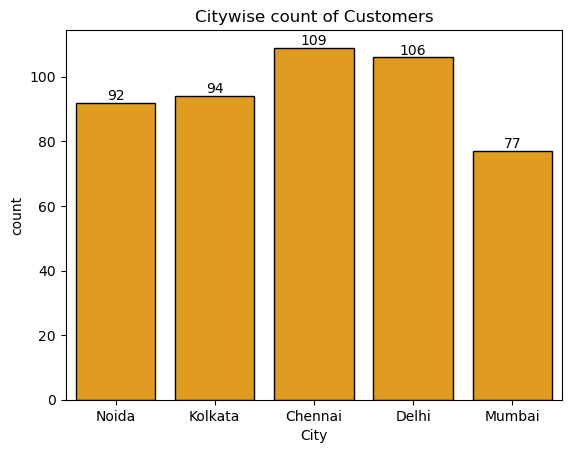

In [10]:
ax = sns.countplot (data=cb,x='City',color='orange',edgecolor='black')
ax.bar_label(ax.containers[0])
plt.title('Citywise count of Customers')
plt.show()

#### Q3) Find Range Age wise count of customers, represent it on pie chart. 

In [11]:
cb['Age_Range'] = pd.cut(cb['Age'],bins=[19,25,30,35,40])
cb['Age_Range'] = cb['Age_Range'].astype(str)
fig = px.pie(cb,names='Age_Range',title='Age_Range wise Customer Count')
fig.show()

#### Q4) Find Count of each activity, represent it on bar chart

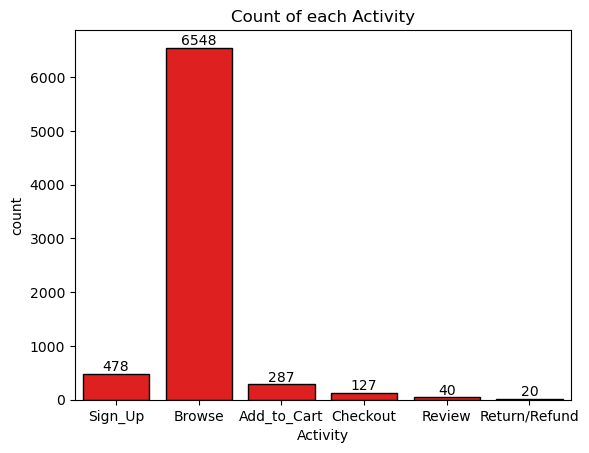

In [12]:
ax = sns.countplot(ca,x='Activity', color='red', edgecolor='black')
ax.bar_label(ax.containers[0])
plt.title('Count of each Activity')
plt.show()

#### 5) Find order month wise total amount. Represent it on line chart.

In [13]:
print(ca.columns)
print(ca.shape)
print(o.columns)
print(o.shape)

Index(['Cust_ID', 'Activity', 'Date'], dtype='object')
(7500, 3)
Index(['Order_id', 'Cust_ID', 'Amount', 'Payment_mode'], dtype='object')
(127, 4)


In [14]:
ca_o = pd.merge(ca,o,on='Cust_ID',how='right')
ca_o = ca_o[ca_o['Activity']=='Checkout']
ca_o.shape

(127, 6)

In [15]:
ca_o['Date'] = pd.to_datetime(ca_o['Date'])
ca_o['Order_Month'] = ca_o['Date'].dt.month
ca_o.head()

,Cust_ID,Activity,Date,Order_id,Amount,Payment_mode,Order_Month
9,CUS_545,Checkout,2024-04-26,ORD_71,2123.19,UPI,4
20,CUS_622,Checkout,2024-02-01,ORD_72,2788.02,Net Banking,2
29,CUS_418,Checkout,2024-07-22,ORD_73,3071.63,Credit_Card,7
41,CUS_360,Checkout,2025-05-24,ORD_74,5736.31,COD,5
52,CUS_714,Checkout,2024-06-19,ORD_75,1592.53,Debit Card,6


In [16]:
q5 = ca_o.groupby(['Order_Month'])['Amount'].sum().reset_index()
q5

,Order_Month,Amount
0,1,27022.20
1,2,70477.42
2,3,74777.59
3,4,88080.66
4,5,60200.46
5,6,69580.07
6,7,80416.05
7,8,27227.29
8,9,34804.62
9,10,30298.38


In [17]:
fig = px.line(q5,x='Order_Month',y='Amount',
              title='Order Month wise Sum of Amount',text="Amount")
fig.show()

#### 6) Find Sub_Plan wise total revenue generated. Represent it on bar chart.


In [18]:
print(sp.columns)
print(sp.shape)
print(cs.columns)
print(cs.shape)

Index(['Plan_Var_ID', 'Plan_ID', 'Plan_name', 'Price', 'Duration'], dtype='object')
(6, 5)
Index(['Cust_ID', 'Plan_Var_ID', 'Purchase_Date'], dtype='object')
(51, 3)


In [19]:
cs_sp = pd.merge(cs,sp,on='Plan_Var_ID',how='inner')
cs_sp.shape

(51, 7)

In [20]:
q6 = cs_sp.groupby(['Plan_Var_ID'])['Price'].sum().reset_index()
q6

,Plan_Var_ID,Price
0,P1_1Y,16800.0
1,P1_6M,5040.0
2,P2_1Y,24000.0
3,P2_6M,7200.0
4,P3_1Y,28800.0
5,P3_6M,25920.0


In [21]:
fig = px.bar(q6,x='Plan_Var_ID',y='Price',text='Price',
       title='Subscription Plan wise Total Amount')
fig.show()

#### 7) City wise find total amount. Represent it on bar chart


In [22]:
print(cb.columns)
print(o.columns)

Index(['Cust_ID', 'City', 'Age', 'Age_Range'], dtype='object')
Index(['Order_id', 'Cust_ID', 'Amount', 'Payment_mode'], dtype='object')


In [23]:
cb_o = pd.merge(cb,o,on='Cust_ID',how='inner')
cb_o.shape

(127, 7)

In [24]:
q7 = cb_o.groupby('City')['Amount'].sum().reset_index()
q7

,City,Amount
0,Chennai,96763.72
1,Delhi,147176.17
2,Kolkata,102185.83
3,Mumbai,120515.98
4,Noida,158552.95


In [25]:
fig = px.bar(q7,x='City',y='Amount',text='Amount',
            title='City wise sum of Amount')
fig.show()

#### 8) Find count of each payment mode, represent it on donut chart


In [26]:
q8 = o['Payment_mode'].value_counts().reset_index()
q8

,Payment_mode,count
0,Net Banking,29
1,Debit Card,27
2,UPI,24
3,Credit_Card,24
4,COD,23


In [27]:
fig = px.pie(q8,'Payment_mode','count',hole=0.5,title='Count of Each Payment Mode')
fig.show()

#### 9) Represent Payment mode wise amount on a strip plot

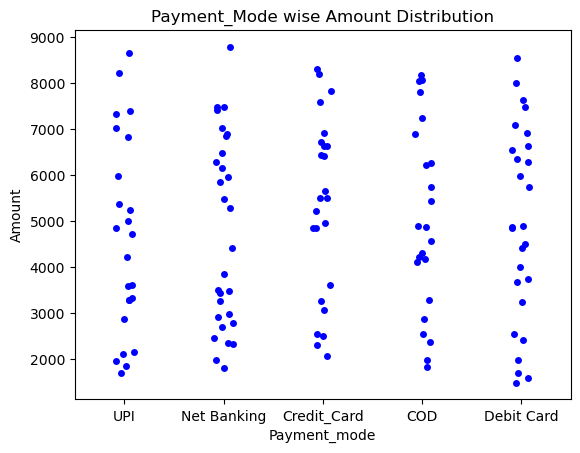

In [28]:
ax = sns.stripplot(data=o, x='Payment_mode', y='Amount',jitter=True, color='blue')
plt.title('Payment_Mode wise Amount Distribution')
plt.show()

## Funnel Analysis

#### 1) Generate Funnel

In [29]:
ca['Cust_ID'].nunique()

681

In [30]:
q10 = ca.groupby(['Cust_ID',
    'Activity'])['Activity'].count().reset_index(name='Count')
q10.head()

,Cust_ID,Activity,Count
0,CUS_121,Add_to_Cart,1
1,CUS_121,Browse,8
2,CUS_121,Checkout,1
3,CUS_121,Sign_Up,1
4,CUS_122,Browse,10


In [31]:
funnel = q10['Activity'].value_counts().reset_index()
funnel

,Activity,count
0,Browse,681
1,Sign_Up,478
2,Add_to_Cart,287
3,Checkout,127
4,Review,40
5,Return/Refund,20


In [32]:
# shift(1) = lead(1)
# shift(-1) = lag(1)
funnel['Prev_Count'] = np.where(funnel['Activity']!='Return/Refund',
                    funnel['count'].shift(1),funnel['count'].shift(2))
funnel

,Activity,count,Prev_Count
0,Browse,681,NaN
1,Sign_Up,478,681.0
2,Add_to_Cart,287,478.0
3,Checkout,127,287.0
4,Review,40,127.0
5,Return/Refund,20,127.0


In [33]:
funnel['Conversion%'] = (funnel['count']/funnel['Prev_Count'])*100
funnel['Loss%'] = 100 - funnel['Conversion%'] 
funnel

,Activity,count,Prev_Count,Conversion%,Loss%
0,Browse,681,NaN,NaN,NaN
1,Sign_Up,478,681.0,70.190896,29.809104
2,Add_to_Cart,287,478.0,60.041841,39.958159
3,Checkout,127,287.0,44.250871,55.749129
4,Review,40,127.0,31.496063,68.503937
5,Return/Refund,20,127.0,15.748031,84.251969


In [34]:
funnel['Prev_Count']  = funnel['Prev_Count'].fillna(0)
funnel['Conversion%']  = funnel['Conversion%'].fillna(100)
funnel['Loss%']  = funnel['Loss%'].fillna(0)
funnel

,Activity,count,Prev_Count,Conversion%,Loss%
0,Browse,681,0.0,100.000000,0.000000
1,Sign_Up,478,681.0,70.190896,29.809104
2,Add_to_Cart,287,478.0,60.041841,39.958159
3,Checkout,127,287.0,44.250871,55.749129
4,Review,40,127.0,31.496063,68.503937
5,Return/Refund,20,127.0,15.748031,84.251969


In [35]:
fig = px.funnel(funnel,x='Conversion%',y='Activity',
         title='Funnel Analysis')
fig.show()

### =========================
### Funnel Analysis Insights
### =========================

1. The highest drop-off (~30%) occurs between Browse and Sign_Up stage.
   This indicates that a significant number of users are not willing to register,
   possibly due to a complex signup process or lack of clear value proposition.

2. A moderate drop (~10%) is observed between Sign_Up and Add_to_Cart,
   suggesting that users are not fully engaged with the products after signing up.

3. A major drop (~16%) occurs at the Add_to_Cart to Checkout stage.
   This is a critical point where users show intent but do not complete the purchase,
   possibly due to pricing, additional costs, or complicated checkout flow.

4. Around ~13% drop is observed between Checkout and Review,
   indicating either incomplete transactions or low post-purchase engagement.

5. The Return/Refund rate (~15%) suggests potential issues with product quality,
   mismatch of expectations, or customer dissatisfaction.

#### Conclusion:
The most critical stages to optimize are:
- Sign_Up stage (reduce friction in onboarding)
- Checkout stage (simplify payment and reduce drop-offs)

Improving these stages can significantly increase overall conversion rate and revenue.


#### 2) Find Customer wise count of days to transition from one stage of funnel to the next stage

In [36]:
ca.head()

,Cust_ID,Activity,Date
0,CUS_121,Sign_Up,2024-04-24
1,CUS_121,Browse,2024-04-27
2,CUS_121,Add_to_Cart,2024-04-27
3,CUS_121,Browse,2024-04-29
4,CUS_121,Browse,2024-04-30


In [37]:
ca['Date'] = ca['Date'].astype(str) 
ca.dtypes

Cust_ID     object
Activity    object
Date        object
dtype: object

In [38]:
q11 = ca.groupby(['Cust_ID','Activity'])['Date'].min().reset_index() #.sort_values(by=['Cust_ID','Date'],ascending=[True,True])
q11.head(20)

,Cust_ID,Activity,Date
0,CUS_121,Add_to_Cart,2024-04-27
1,CUS_121,Browse,2024-04-27
2,CUS_121,Checkout,2024-05-05
3,CUS_121,Sign_Up,2024-04-24
4,CUS_122,Browse,2025-07-12
5,CUS_123,Browse,2024-04-14
6,CUS_124,Add_to_Cart,2025-01-06
7,CUS_124,Browse,2025-01-06
8,CUS_124,Sign_Up,2025-01-05
9,CUS_125,Browse,2024-06-17


In [39]:
# Pivot so each activity becomes a column
result = ca.pivot_table(
    index="Cust_ID", 
    columns="Activity", 
    values="Date", 
    aggfunc="first"   # in case multiple same activities exist
).reset_index()
result

Activity,Cust_ID,Add_to_Cart,Browse,Checkout,Return/Refund,Review,Sign_Up
0,CUS_121,2024-04-27,2024-04-27,2024-05-05,NaN,NaN,2024-04-24
1,CUS_122,NaN,2025-07-12,NaN,NaN,NaN,NaN
2,CUS_123,NaN,2024-04-14,NaN,NaN,NaN,NaN
3,CUS_124,2025-01-06,2025-01-06,NaN,NaN,NaN,2025-01-05
4,CUS_125,NaN,2024-06-17,NaN,NaN,NaN,2024-06-15
...,...,...,...,...,...,...,...
676,CUS_797,NaN,2024-03-19,NaN,NaN,NaN,2024-03-15
677,CUS_798,NaN,2025-03-22,NaN,NaN,NaN,2025-03-19
678,CUS_799,NaN,2025-07-12,NaN,NaN,NaN,NaN
679,CUS_800,NaN,2024-02-25,NaN,NaN,NaN,NaN


In [40]:
# Convert all stage columns to datetime
cols = ['Browse', 'Sign_Up', 'Add_to_Cart', 'Checkout']

for col in cols:
    result[col] = pd.to_datetime(result[col])

In [41]:
result['Browse_to_SignUp'] = (result['Browse'] - result['Sign_Up']).dt.days

result['SignUp_to_AddCart'] = (result['Add_to_Cart'] - result['Sign_Up']).dt.days

result['AddCart_to_Checkout'] = (result['Checkout'] - result['Add_to_Cart']).dt.days

result.head()

Activity,Cust_ID,Add_to_Cart,Browse,Checkout,Return/Refund,Review,Sign_Up,Browse_to_SignUp,SignUp_to_AddCart,AddCart_to_Checkout
0,CUS_121,2024-04-27,2024-04-27,2024-05-05,NaN,NaN,2024-04-24,3.0,3.0,8.0
1,CUS_122,NaT,2025-07-12,NaT,NaN,NaN,NaT,NaN,NaN,NaN
2,CUS_123,NaT,2024-04-14,NaT,NaN,NaN,NaT,NaN,NaN,NaN
3,CUS_124,2025-01-06,2025-01-06,NaT,NaN,NaN,2025-01-05,1.0,1.0,NaN
4,CUS_125,NaT,2024-06-17,NaT,NaN,NaN,2024-06-15,2.0,NaN,NaN


In [42]:
cols = ['Add_to_Cart', 'Browse', 'Checkout', 'Return/Refund',
       'Review', 'Sign_Up']

for i in cols:
    result[i] = pd.to_datetime(result[i])

#### 3) Find Avg_Days to transition from one Funnel stage to the next stage.

In [43]:
avg_days = result[['Browse_to_SignUp',
                   'SignUp_to_AddCart',
                   'AddCart_to_Checkout']].mean()

avg_days

Activity
Browse_to_SignUp        1.550209
SignUp_to_AddCart       2.512195
AddCart_to_Checkout    14.425197
dtype: float64

In [44]:
avg_days_df = avg_days.reset_index()
avg_days_df.columns = ['Stage_Transition', 'Avg_Days']

avg_days_df

,Stage_Transition,Avg_Days
0,Browse_to_SignUp,1.550209
1,SignUp_to_AddCart,2.512195
2,AddCart_to_Checkout,14.425197


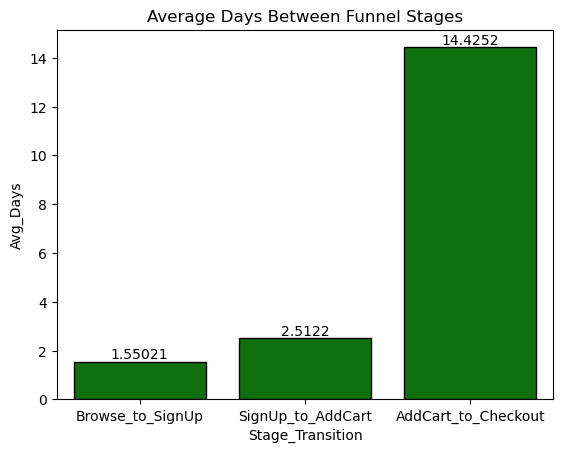

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(data=avg_days_df, x='Stage_Transition', y='Avg_Days',color='green',edgecolor='black')
ax.bar_label(ax.containers[0])
plt.title('Average Days Between Funnel Stages')
plt.xticks
plt.show()

#### 4) Create function to analyse Funnel based on City. 

In [46]:
ca = pd.merge(ca, cb[['Cust_ID', 'City']], on='Cust_ID', how='left')

In [47]:
def city_funnel_analysis(df, city_name):
    
    
    df_city = df[df['City'] == city_name]
    stages = ['Browse', 'Sign_Up', 'Add_to_Cart', 'Checkout']
    
    funnel_data = []
    for stage in stages:
        count = df_city[df_city['Activity'] == stage]['Cust_ID'].nunique()
        funnel_data.append(count)
    
    funnel_df = pd.DataFrame({'Stage': stages,'Users': funnel_data})
    
    print(f"\nFunnel Analysis for {city_name}")
    print(funnel_df)
    
    fig = px.funnel(funnel_df, x='Users', y='Stage',title=f'Funnel Analysis - {city_name}')
    fig.show()
    
    return funnel_df


Funnel Analysis for Delhi
         Stage  Users
0       Browse    106
1      Sign_Up    106
2  Add_to_Cart     60
3     Checkout     30


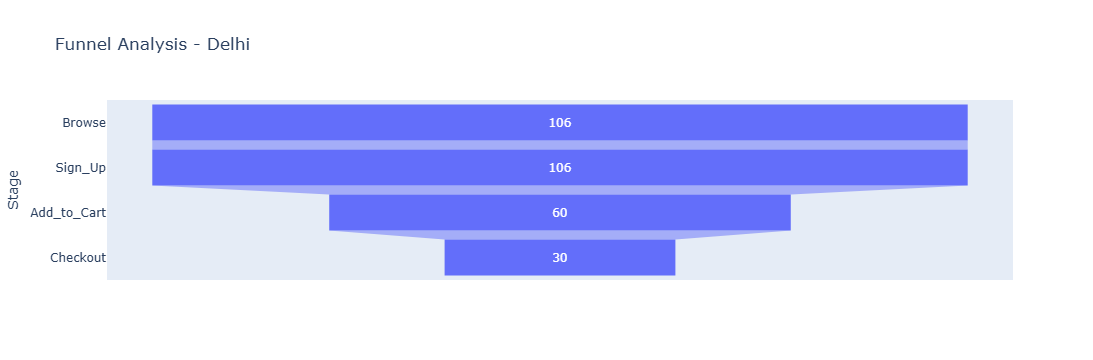


Funnel Analysis for Mumbai
         Stage  Users
0       Browse     77
1      Sign_Up     77
2  Add_to_Cart     49
3     Checkout     23


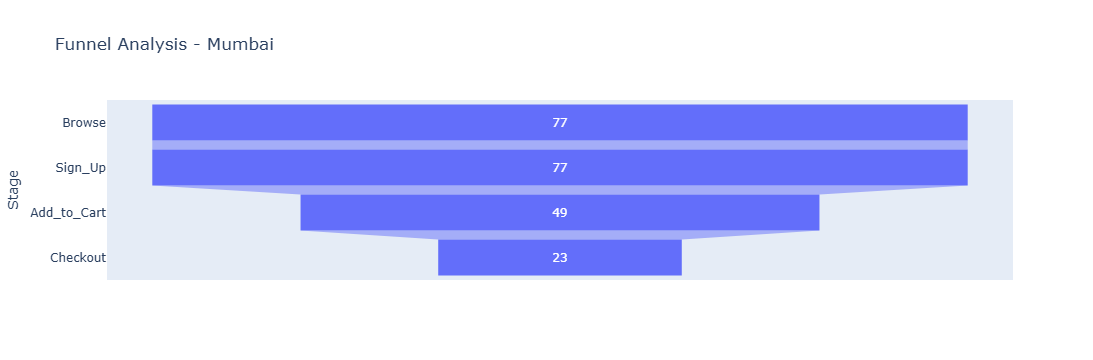


Funnel Analysis for Kolkata
         Stage  Users
0       Browse     94
1      Sign_Up     94
2  Add_to_Cart     54
3     Checkout     22


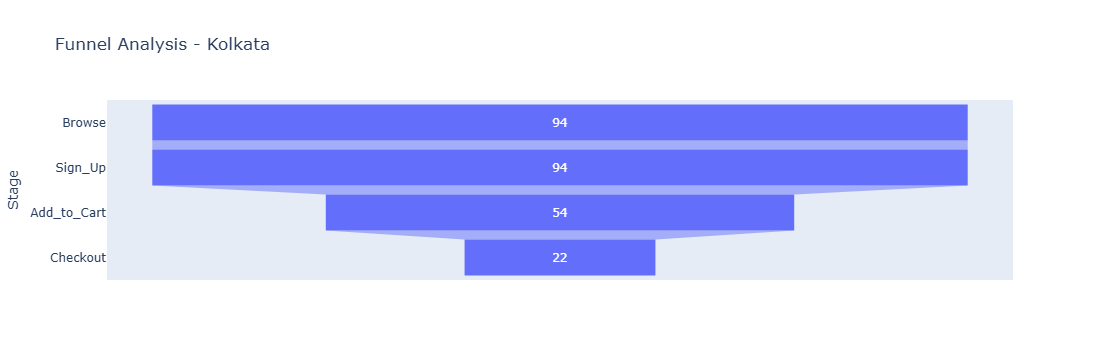


Funnel Analysis for Chennai
         Stage  Users
0       Browse    109
1      Sign_Up    109
2  Add_to_Cart     62
3     Checkout     18


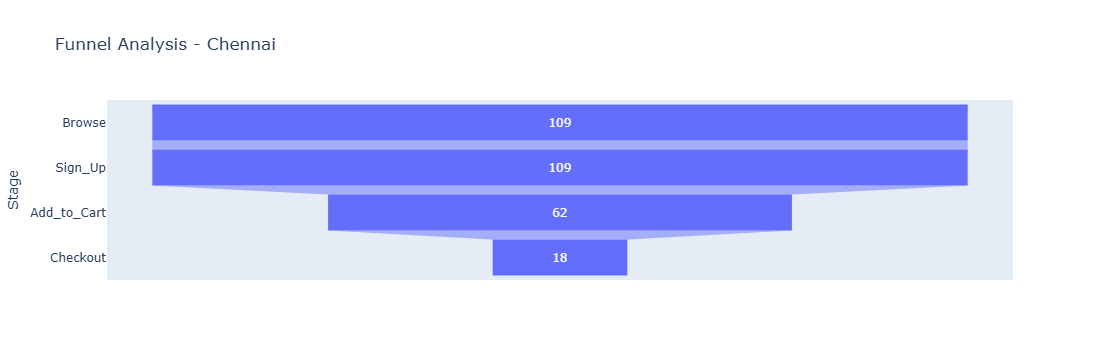


Funnel Analysis for Noida
         Stage  Users
0       Browse     92
1      Sign_Up     92
2  Add_to_Cart     62
3     Checkout     34


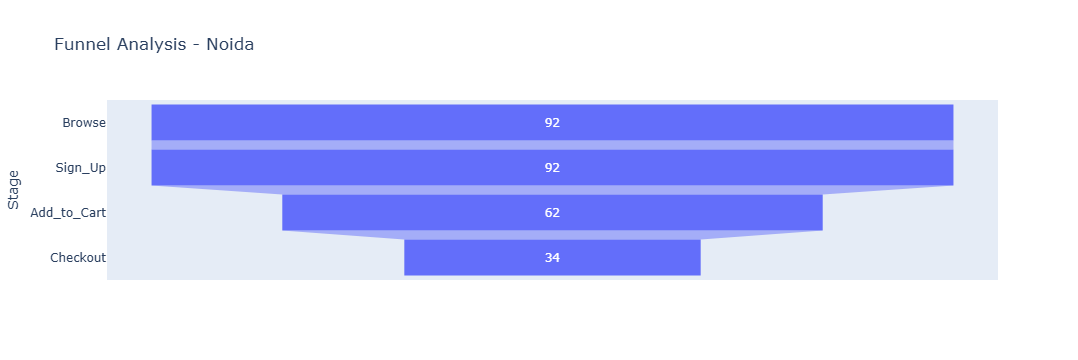

,Stage,Users
0,Browse,92
1,Sign_Up,92
2,Add_to_Cart,62
3,Checkout,34


In [48]:
city_funnel_analysis(ca, 'Delhi')
city_funnel_analysis(ca, 'Mumbai')
city_funnel_analysis(ca, 'Kolkata')
city_funnel_analysis(ca, 'Chennai')
city_funnel_analysis(ca, 'Noida')

### Key Insights

- Users take the highest time to transition from Add_to_Cart to Checkout.
- Certain cities show lower conversion rates compared to others.
- Funnel indicates potential friction in the checkout process.


### Business Recommendations

- Optimize checkout flow to reduce delays and drop-offs.
- Offer targeted promotions in low-performing cities.
- Simplify payment process to improve final conversion rate.


### Conclusion

- This project analyzed user behavior across different funnel stages using SQL and Python.
- By identifying drop-offs, transition delays, and city-level differences, we derived actionable insights to improve conversion rates and user experience.


### Future Scope

- Analyze user behavior based on device type.
- Include cohort analysis for retention tracking.
- Perform A/B testing on funnel stages.